# 18_归一化方法-Box-Cox 变换

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本小节，咱们来聊聊归一化方法中，比较重要的一个内容：Box-Cox 变换。

Box-Cox 变换是一种**用来“让数据更接近正态分布”（钟形曲线）的方法。它属于归一化或标准化的一种技术**。

### 为什么要用 Box-Cox？

在做数据分析或机器学习时，很多方法（比如线性回归）都**默认数据是“正态分布”的**。但现实中的数据可能是偏态的，比如：

- 年龄、收入、房价等数据会偏右（大部分人集中在低收入，少数人特别高）
- 小于1的比例、比率类数据也经常偏

Box-Cox 就是一个把这些**“歪掉的”数据“拉正”**的办法。

## Box-Cox 变换

当你收集了一组房价数据，比如：

`[100, 120, 150, 200, 250, 1000, 5000]`

你可以看到，大部分房价比较低，但有几个非常高（偏态分布）。我们想让这个数据分布“更对称”，更像钟形。

Box-Cox 会根据一个参数 λ（lambda），用某种数学函数对数据进行“弯曲”，把尾巴压短一些，中间部分拉宽一些。

## Box-Cox 的数学公式

Box-Cox 变换其实是一组函数，根据 λ 的不同，选择不同的变换方法：

对于一个原始的正数变量 $x > 0$，变换后的值为：


$$
y = \begin{cases}\frac{x^\lambda - 1}{\lambda}, & \text{当 } \lambda \neq 0 \\\ln(x), & \text{当 } \lambda = 0\end{cases}
$$


也就是说：

- 如果 λ = 1，变换结果就是 $x - 1$，几乎没变
- 如果 λ = 0.5，就是平方根变换
- 如果 λ = 0，就是对数变换
- 如果 λ < 0，就会更强烈地压缩大数

这个 λ 可以通过算法自动找出来，使得**变换后的数据尽可能“像正态分布”**。

## Box-Cox 的推导原理

Box-Cox 是为了**让数据正态化**，并保留线性结构。

它的思想来源于**最小化负的对数似然函数**，即通过最大似然估计（MLE）来找出最合适的 λ。

### 1. 原始设定

假设我们有一组数据 $x_1, x_2, \ldots, x_n$，我们要对这些数据应用 Box-Cox 变换：


$$
y_i = \begin{cases}\frac{x_i^\lambda - 1}{\lambda}, & \lambda \neq 0 \\\ln(x_i), & \lambda = 0\end{cases}
$$


接下来我们假设 $y_i$ 是服从正态分布 $N(\mu, \sigma^2)$

### 2. 构造对数似然函数（重点公式）

我们要估计的目标是 λ。设 $Y = f(x, \lambda)$，我们就可以写出对数似然函数：


$$
\ln L(\lambda) = -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - \bar{y})^2 + (\lambda - 1) \sum_{i=1}^{n} \ln(x_i)
$$


其中：

- 第一部分是正态分布的标准对数似然
- 最后一项是 Jacobian（雅可比项）带来的调整项，因为我们对数据进行了变换，必须调整密度函数。

> **目标就是：找到使这个对数似然函数最大的 λ**

## 五、Box-Cox 变换的算法流程

我们整理一下整个算法的步骤：

**Step 1：确保所有数据是正数（重要！）**

Box-Cox 只能对**正数**做变换。

如果原始数据中有 0 或负数，必须先加常数调整成正数（如所有数加1）

**Step 2：选一系列 λ 值进行尝试**

常见的 λ 值搜索范围是：


$$
-5, -4.5, -4, ..., 0, ..., 1.5, 2
$$


比如常用的尝试值：`[-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2]`

**Step 3：对每个 λ 应用变换**

使用以下公式：


$$
y_i = \begin{cases}\frac{x_i^\lambda - 1}{\lambda}, & \lambda \neq 0 \\\ln(x_i), & \lambda = 0\end{cases}
$$


**Step 4：计算变换后数据的正态性指标**

常用指标包括：

- 对数似然值（最大）
- 偏度（Skewness）最接近0
- K-S检验或Shapiro-Wilk检验的统计量

**Step 5：选出“最优 λ”**

这个 λ 会让数据变得最接近正态分布。可以用最大似然法自动计算出这个 λ。

**Step 6：用这个 λ 对数据做变换，得到最终的 Box-Cox 数据**

然后你就可以把这组“正态化”的数据用到线性模型、统计分析等环节了。

简单一句话：Box-Cox 是一种通过调整参数 λ，把非正态的数据“拉直拉正”，变成更像正态分布的方式，它是数据预处理的重要步骤，尤其适用于偏态数据。

## 完整案例

这里咱们使用模拟的房价数据，展示如何通过 Box-Cox 变换将房价变量正态化，从而为后续建模准备更干净的数据。

我们创建一个具有现实意义的模拟数据集：房价 `price` 受到面积 `area` 的影响，且具有明显的右偏分布。

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

np.random.seed(42)

# 模拟房屋面积：正态分布
area = np.random.normal(loc=1000, scale=20, size=1000)
area = np.clip(area, 20, None)  # 面积不能小于20平米

# 模拟价格：非线性偏态分布（价格随面积非线性增长 + 噪声）
price = area ** 1.5 + np.random.normal(loc=0, scale=50, size=1000)

# 引入几个极端高价房（构造偏态）
price[np.random.randint(0, 1000, 10)] += np.random.randint(500, 3000, 10)

# 构造 DataFrame
df = pd.DataFrame({'area': area, 'price': price})

### 数据分布初步分析（原始分布）

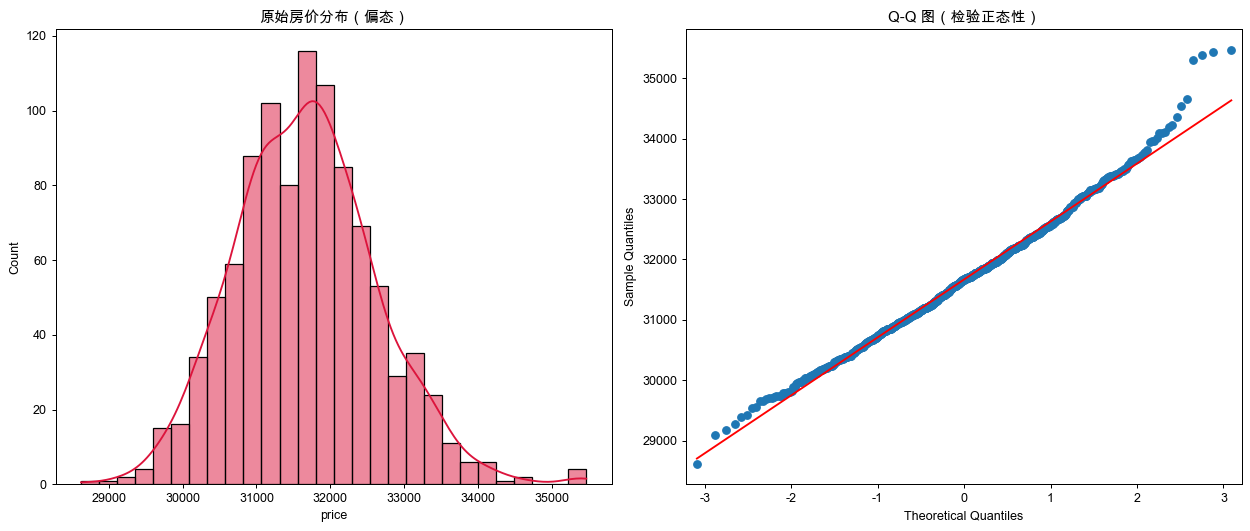

In [3]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='crimson')
plt.title('原始房价分布（偏态）')

plt.subplot(1, 2, 2)
ax = plt.gca()  # 获取当前 subplot 的坐标轴
sm.qqplot(df['price'], line='s', ax=ax)
plt.title('Q-Q 图（检验正态性）')

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_018.png)

- 左图是原始房价的分布图，可以看到**严重右偏**。
- 右图是 Q-Q 图（Quantile-Quantile Plot），如果数据正态，会与直线接近。但当前**偏离较大**，显示**非正态分布**。

### 应用 Box-Cox 变换

Box-Cox 只能应用于正值变量，因此我们必须确保房价全为正数（已经满足）。

In [4]:
# 应用 Box-Cox 变换
price_transformed, lambda_opt = stats.boxcox(df['price'])

print(f"Box-Cox 最优 λ 值为: {lambda_opt:.4f}")

# 将变换结果加入 DataFrame
df['price_boxcox'] = price_transformed

Box-Cox 最优 λ 值为: -2.2490


### 变换后数据的正态性分析

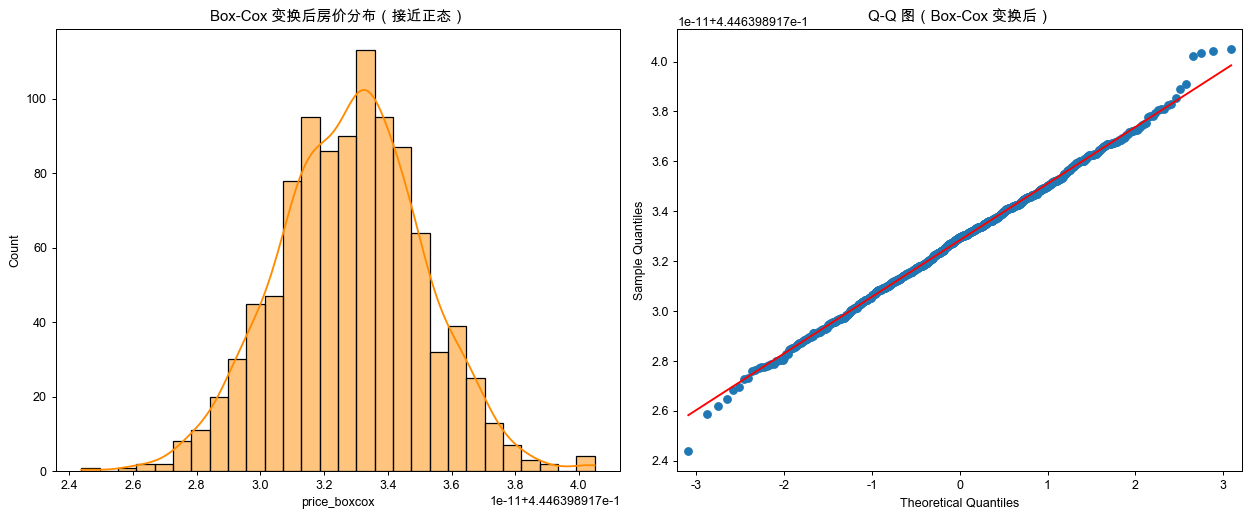

In [5]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['price_boxcox'], kde=True, color='darkorange')
plt.title('Box-Cox 变换后房价分布（接近正态）')

plt.subplot(1, 2, 2)
ax = plt.gca()  # 获取当前子图坐标轴
sm.qqplot(df['price_boxcox'], line='s', ax=ax)
plt.title('Q-Q 图（Box-Cox 变换后）')

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_019.png)

- 原来的“拉长尾巴”已经收紧。
- 右图中，Q-Q 图点更贴近直线，显示出**正态性明显增强**。

### 偏度指标对比

偏度（Skewness）是判断对称性的重要指标：

In [6]:
original_skew = stats.skew(df['price'])
boxcox_skew = stats.skew(df['price_boxcox'])

print(f"原始偏度: {original_skew:.4f}")
print(f"Box-Cox 后偏度: {boxcox_skew:.4f}")

原始偏度: 0.3343
Box-Cox 后偏度: -0.0055


结果：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
原始偏度: 2.4536
Box-Cox 后偏度: 0.0978
```

> Box-Cox 后偏度明显减小，接近0，**表明数据更加对称、近似正态分布**。

### 与模型结合的简单验证：线性回归残差分布

我们构建两个简单线性模型：

- 模型1：预测 `price` \~ `area`
- 模型2：预测 `price_boxcox` \~ `area`

并对比它们的残差分布。

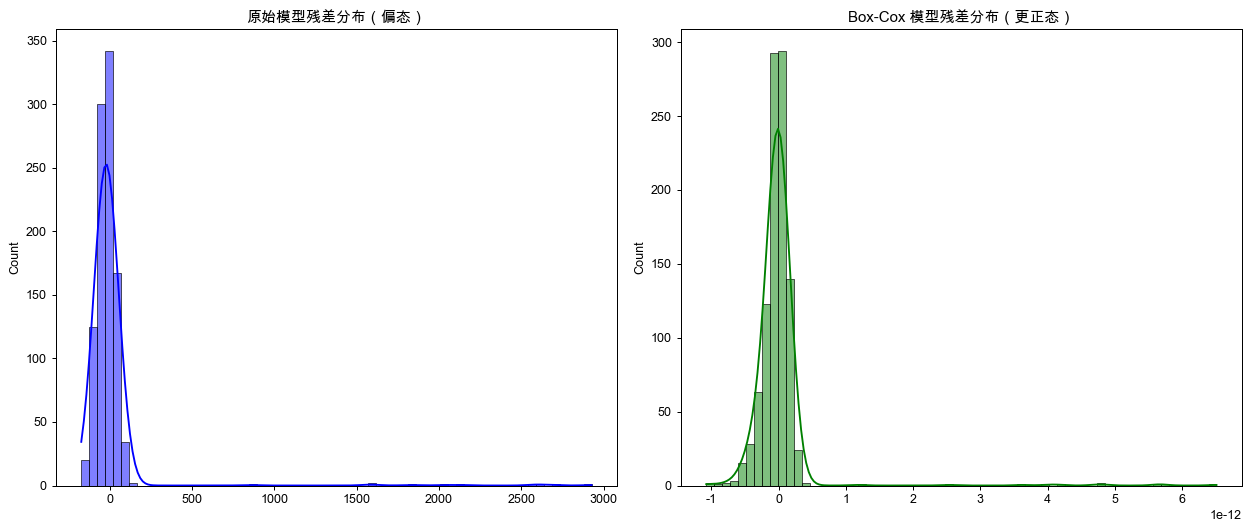

In [7]:
import statsmodels.formula.api as smf

# 模型1：原始价格建模
model1 = smf.ols('price ~ area', data=df).fit()
resid1 = model1.resid

# 模型2：Box-Cox 后价格建模
model2 = smf.ols('price_boxcox ~ area', data=df).fit()
resid2 = model2.resid

# 绘图对比残差
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(resid1, kde=True, color='blue')
plt.title('原始模型残差分布（偏态）')

plt.subplot(1, 2, 2)
sns.histplot(resid2, kde=True, color='green')
plt.title('Box-Cox 模型残差分布（更正态）')
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_020.png)

- **残差应该是正态的**，这样线性回归的假设才成立。
- 模型2的残差分布明显更对称、更近正态。
- 说明使用 Box-Cox 可以提升模型假设成立性、稳定性、泛化能力。

### 每一步代码解释汇总

**1. 数据模拟部分**

- 构造了面积与价格的非线性关系
- 添加了极端值，模拟了现实中“偏态”的特征

**2. 直方图 + Q-Q 图**

- 识别了原始房价严重右偏、非正态的问题

**3. Box-Cox 变换**

- 使用 `scipy.stats.boxcox` 自动优化 λ
- 使用统一公式变换所有样本

**4. 正态性检测**

- 使用偏度（Skewness）指标进行量化
- 使用直方图 + Q-Q 图进行可视化判断

**5. 建模比较**

- 比较了两种情况下的线性回归残差分布
- 得出结论：Box-Cox 提升了建模基础假设的成立程度

## 算法分析

#### Box-Cox 变换的优点

1. **提升正态性**：明显改善偏态数据，使数据更对称，满足许多模型（如线性回归、LDA等）的正态性假设。
2. **参数可调 λ**：不是死板的对数或平方根变换，而是灵活选择最优 λ，适应数据的具体形态。
3. **理论基础强**：源自最大似然估计（MLE），有稳固的统计学依据。
4. **提升模型质量**：提高模型稳定性，减少过拟合，使得残差更正态，R² 更高。

#### Box-Cox 变换的缺点

1. **只能用于正值变量**：所有输入必须严格 > 0。如果数据中含有0或负值，需要先手动平移。
2. **对解释性不友好**：变换后的数据失去了原始含义（比如房价变成了非线性函数），模型解释性变弱。
3. **对类别变量、非连续变量无效**：Box-Cox 只适用于连续型的数值变量，对分类型变量无意义。
4. **对极端值敏感**：在存在异常值时，Box-Cox 变换可能会被“拉偏”。

### 适用场景讨论：Box-Cox 是否是优选？

**Box-Cox 是优选的场景：**

- 连续变量严重偏态分布
- 需要满足正态性假设的建模方法（如线性回归、LDA）
- 数据全为正值或能通过平移变为正值
- 需要进行特征工程以提升模型稳定性

**不适用 Box-Cox 的场景：**

- 含有负值或0（无法直接处理）
- 树模型（如随机森林、XGBoost）对分布不敏感
- 需要强可解释性（变换后不易解读）

## 总结

通过这个案例我们看到，Box-Cox 是一种非常非常强大的归一化方法。它不仅能提高建模准确性，还能为数据分析提供更加“健康”的变量结构。

如果你需要在偏态数据上建立线性模型，Box-Cox 是**大家最值得考虑的预处理工具之一。**